01. Environment Check
Python  : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
OS      : Windows 10
PyTorch : 2.6.0+cu124
CUDA    : True
02. Package installation complete.
03. All libraries imported successfully.
04. Configuration set.
    Total models: 6

05. Loading prediction CSVs from Notebook 03 ...
    Loaded: VGG-16 (RGB)                   (54,000 samples)
    Loaded: VGG-16 (RGB+FFT)               (54,000 samples)
    Loaded: VGG-16 3-Stream                (54,000 samples)
    Loaded: Xception (RGB)                 (54,000 samples)
    Loaded: Xception (RGB+FFT)             (54,000 samples)
    Loaded: SFRPD-Net (Ours)               (54,000 samples)
    Total loaded: 6 / 6

06. Computing metrics for all models ...

Model Comparison Table
             Model                   Reference     Type  Accuracy    AUC  Precision  Recall     F1
      VGG-16 (RGB) Simonyan & Zisserman (2014) Baseline    0.9636 0.9954     0.9749  0.9623 0.9

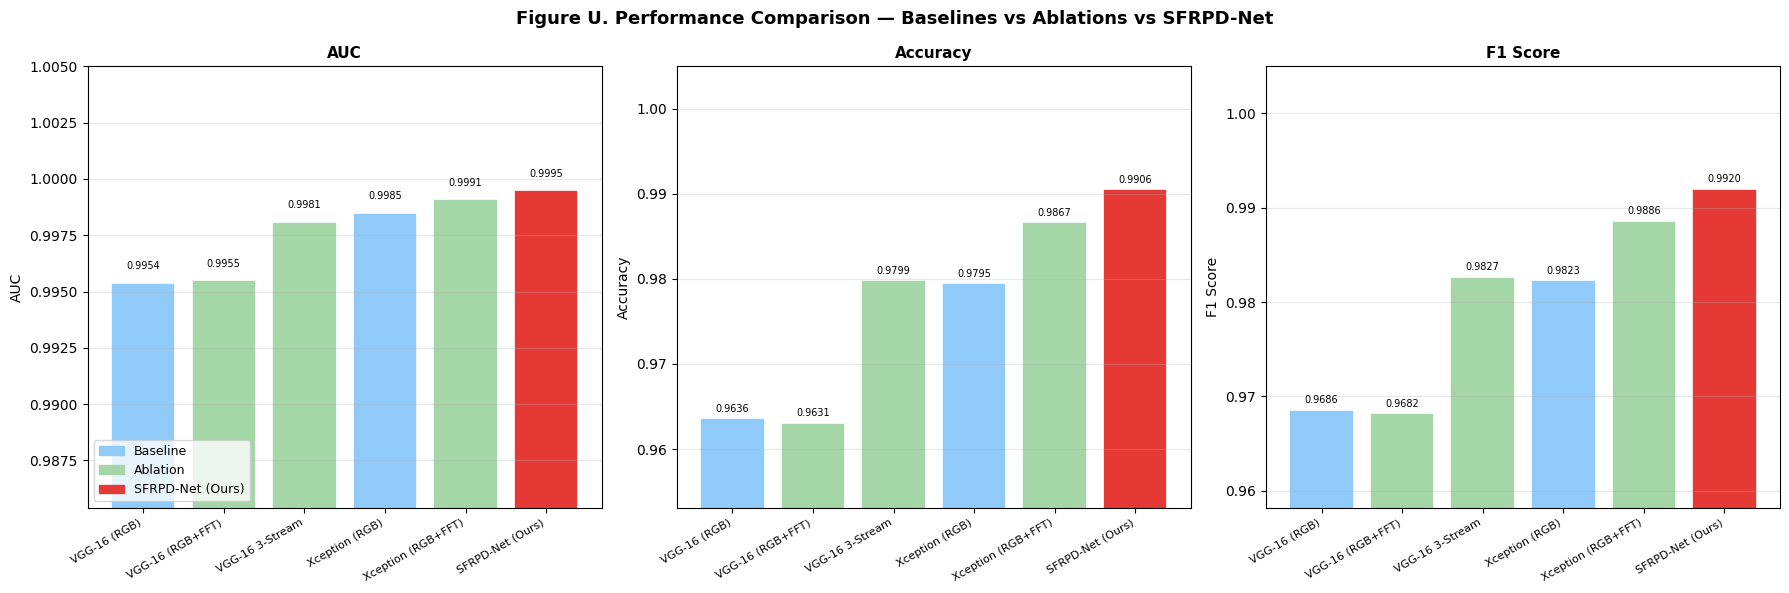

    Saved → eda_outputs/FigU_sota_comparison_bar.png
09. Figure V: ROC Curves ...


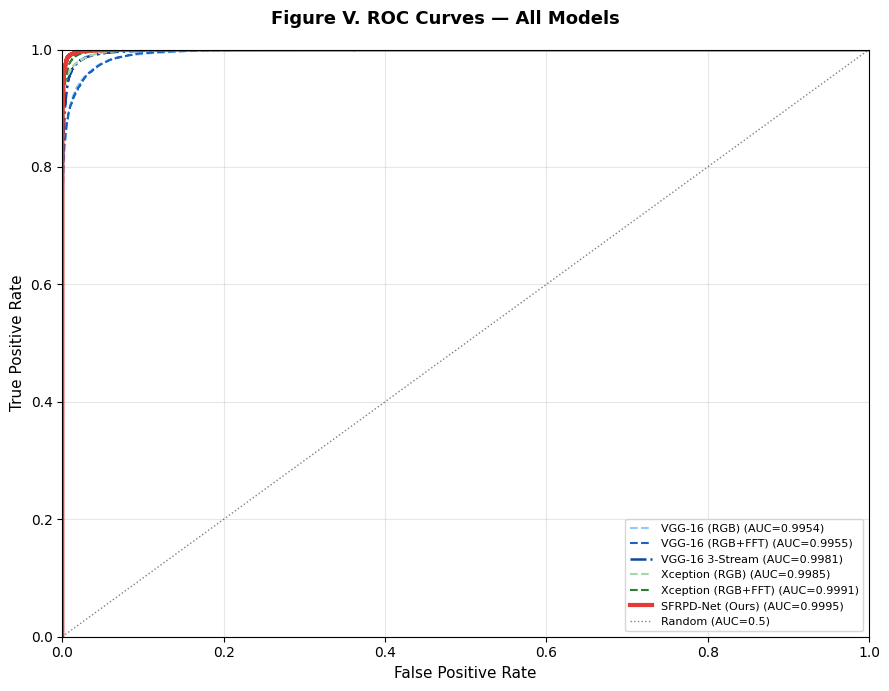

    Saved → eda_outputs/FigV_roc_sota.png
10. Figure W: Radar Chart ...


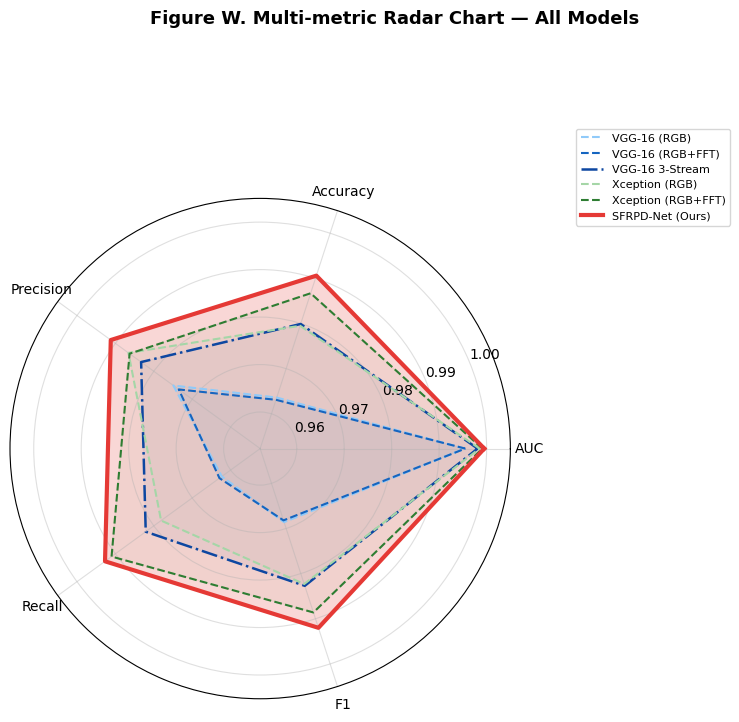

    Saved → eda_outputs/FigW_radar_sota.png
11. Figure X: McNemar p-value Chart ...


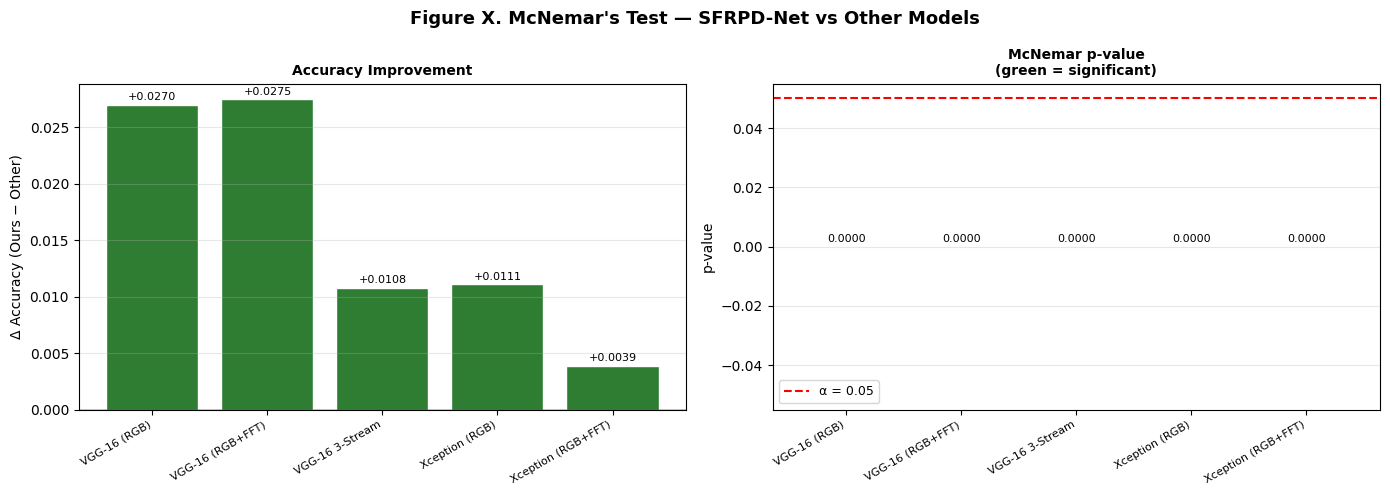

    Saved → eda_outputs/FigX_mcnemar_bar.png

12. Final Paper Table — SOTA Comparison
 Rank              Model                   Reference Accuracy     AUC Precision  Recall      F1
    1   SFRPD-Net (Ours)                   This work  0.9906* 0.9995*   0.9912* 0.9927* 0.9920*
    2 Xception (RGB+FFT)       Xception + FFT (Ours)   0.9867  0.9991    0.9863  0.9910  0.9886
    3     Xception (RGB)       Rossler et al. (2019)   0.9795  0.9985    0.9866  0.9781  0.9823
    4    VGG-16 3-Stream      VGG-16 3-Stream (Ours)   0.9799  0.9981    0.9833  0.9821  0.9827
    5   VGG-16 (RGB+FFT)         VGG-16 + FFT (Ours)   0.9631  0.9955    0.9735  0.9629  0.9682
    6       VGG-16 (RGB) Simonyan & Zisserman (2014)   0.9636  0.9954    0.9749  0.9623  0.9686
  (* = best)

    Saved → sota_outputs/paper_sota_table.csv

13. Summary

  SFRPD-Net (Ours)  : AUC=0.9995 Acc=0.9906 F1=0.9920
  Best Baseline     : Xception (RGB) AUC=0.9985 Acc=0.9795

  ΔAUC  vs best baseline : +0.0010
  ΔAcc  vs best bas

In [1]:
# =============================================================
# Notebook Name: 08_sota_comparison.ipynb
# Project     : Multi-Stream Deepfake Detection (SFRPD-Net Extension)
# Experiments : EXP-10 SOTA Comparison (reusing Notebook 03 results)
# =============================================================

# ─────────────────────────────────────────
# 01. Environment Check
# ─────────────────────────────────────────
import sys, torch, platform

print("=" * 50)
print("01. Environment Check")
print("=" * 50)
print(f"Python  : {sys.version}")
print(f"OS      : {platform.system()} {platform.release()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print("=" * 50)


# ─────────────────────────────────────────
# 02. Install Required Packages
# ─────────────────────────────────────────
import subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

pip_install("scikit-learn")
pip_install("matplotlib")
pip_install("seaborn")
pip_install("statsmodels")
print("02. Package installation complete.")


# ─────────────────────────────────────────
# 03. Import Libraries
# ─────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_curve, auc as sk_auc,
    accuracy_score, f1_score,
    precision_score, recall_score,
)
from statsmodels.stats.contingency_tables import mcnemar

print("03. All libraries imported successfully.")


# ─────────────────────────────────────────
# 04. Paths & Configuration
# ─────────────────────────────────────────
EXPORT_DIR = Path("./export")
EDA_DIR    = Path("./eda_outputs")
SOTA_DIR   = Path("./sota_outputs")

for d in [EDA_DIR, SOTA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Notebook 03 experiment names → paper-friendly display names
MODEL_MAP = {
    "vgg16_rgb"         : "VGG-16 (RGB)",
    "vgg16_rgb_fft"     : "VGG-16 (RGB+FFT)",
    "vgg16_rgb_fft_phy" : "VGG-16 3-Stream",
    "xcep_rgb"          : "Xception (RGB)",
    "xcep_rgb_fft"      : "Xception (RGB+FFT)",
    "xcep_rgb_fft_phy"  : "SFRPD-Net (Ours)",
}

# Map to reference citation
REF_MAP = {
    "vgg16_rgb"         : "Simonyan & Zisserman (2014)",
    "vgg16_rgb_fft"     : "VGG-16 + FFT (Ours)",
    "vgg16_rgb_fft_phy" : "VGG-16 3-Stream (Ours)",
    "xcep_rgb"          : "Rossler et al. (2019)",
    "xcep_rgb_fft"      : "Xception + FFT (Ours)",
    "xcep_rgb_fft_phy"  : "This work",
}

# Model type for coloring
TYPE_MAP = {
    "vgg16_rgb"         : "Baseline",
    "vgg16_rgb_fft"     : "Ablation",
    "vgg16_rgb_fft_phy" : "Ablation",
    "xcep_rgb"          : "Baseline",
    "xcep_rgb_fft"      : "Ablation",
    "xcep_rgb_fft_phy"  : "Ours",
}

COLOR_MAP = {
    "Baseline" : "#90CAF9",
    "Ablation" : "#A5D6A7",
    "Ours"     : "#E53935",
}

EXP_NAMES = list(MODEL_MAP.keys())
print("04. Configuration set.")
print(f"    Total models: {len(EXP_NAMES)}")


# ─────────────────────────────────────────
# 05. Load All Prediction CSVs
# ─────────────────────────────────────────
print("\n05. Loading prediction CSVs from Notebook 03 ...")

pred_records = {}
for name in EXP_NAMES:
    path = EXPORT_DIR / f"{name}_test_predictions.csv"
    if path.exists():
        pred_records[name] = pd.read_csv(path)
        print(f"    Loaded: {MODEL_MAP[name]:30s} "
              f"({len(pred_records[name]):,} samples)")
    else:
        print(f"    [MISSING] {name} — run Notebook 03 first.")

print(f"    Total loaded: {len(pred_records)} / {len(EXP_NAMES)}")


# ─────────────────────────────────────────
# 06. Compute Full Metrics for All Models
# ─────────────────────────────────────────
print("\n06. Computing metrics for all models ...")

rows = []
for name in EXP_NAMES:
    if name not in pred_records:
        continue
    df_p   = pred_records[name]
    y_true = df_p["label"].values
    y_prob = df_p["prob_fake"].values
    y_pred = df_p["pred"].values

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    rows.append({
        "exp_name"  : name,
        "Model"     : MODEL_MAP[name],
        "Reference" : REF_MAP[name],
        "Type"      : TYPE_MAP[name],
        "Accuracy"  : round(accuracy_score(y_true, y_pred), 4),
        "AUC"       : round(sk_auc(fpr, tpr), 4),
        "Precision" : round(precision_score(y_true, y_pred,
                                            zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, y_pred,
                                         zero_division=0), 4),
        "F1"        : round(f1_score(y_true, y_pred,
                                     zero_division=0), 4),
    })

df_compare = pd.DataFrame(rows)
df_compare.to_csv(SOTA_DIR / "sota_comparison.csv", index=False)

print("\n" + "=" * 75)
print("Model Comparison Table")
print("=" * 75)
print(df_compare[[
    "Model","Reference","Type","Accuracy","AUC","Precision","Recall","F1"
]].to_string(index=False))
print(f"\n    Saved → sota_outputs/sota_comparison.csv")


# ─────────────────────────────────────────
# 07. McNemar's Test — SFRPD-Net vs All Others
# ─────────────────────────────────────────
print("\n07. McNemar's Test: SFRPD-Net vs all models ...")

ours_name = "xcep_rgb_fft_phy"
ours_data = pred_records[ours_name]
y_true    = ours_data["label"].values
pred_ours = ours_data["pred"].values

mcnemar_rows = []
for name in EXP_NAMES:
    if name == ours_name or name not in pred_records:
        continue
    pred_b = pred_records[name]["pred"].values

    cc = np.sum((pred_ours == y_true) & (pred_b == y_true))
    cw = np.sum((pred_ours == y_true) & (pred_b != y_true))
    wc = np.sum((pred_ours != y_true) & (pred_b == y_true))
    ww = np.sum((pred_ours != y_true) & (pred_b != y_true))

    result  = mcnemar([[cc,cw],[wc,ww]], exact=False, correction=True)
    acc_b   = accuracy_score(y_true, pred_b)
    acc_o   = accuracy_score(y_true, pred_ours)
    delta   = acc_o - acc_b
    is_sig  = result.pvalue < 0.05

    mcnemar_rows.append({
        "vs Model"   : MODEL_MAP[name],
        "Acc_Ours"   : round(acc_o, 4),
        "Acc_Other"  : round(acc_b, 4),
        "Delta_Acc"  : round(delta, 4),
        "chi2"       : round(result.statistic, 4),
        "p_value"    : round(result.pvalue, 6),
        "Significant": "YES" if is_sig else "NO",
    })
    print(f"    SFRPD-Net vs {MODEL_MAP[name]:25s} → "
          f"Δ={delta:+.4f} p={result.pvalue:.6f} "
          f"{'✓ Sig.' if is_sig else '✗ Not sig.'}")

df_mcn = pd.DataFrame(mcnemar_rows)
df_mcn.to_csv(SOTA_DIR / "mcnemar_vs_sota.csv", index=False)
n_sig = (df_mcn["Significant"] == "YES").sum()
print(f"\n    Significant: {n_sig}/{len(df_mcn)} pairs (p<0.05)")
print(f"    Saved → sota_outputs/mcnemar_vs_sota.csv")


# ─────────────────────────────────────────
# 08. Figure U — SOTA Comparison Bar Chart
# ─────────────────────────────────────────
print("\n08. Figure U: SOTA Comparison Bar Chart ...")

metrics  = ["AUC", "Accuracy", "F1"]
titles   = ["AUC", "Accuracy", "F1 Score"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Figure U. Performance Comparison — Baselines vs Ablations vs SFRPD-Net",
    fontsize=13, fontweight="bold")

x      = np.arange(len(df_compare))
colors = [COLOR_MAP[t] for t in df_compare["Type"]]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(x, df_compare[metric].values,
                  color=colors, edgecolor="white", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(df_compare["Model"].tolist(),
                       rotation=30, ha="right", fontsize=8)
    ymin = max(0.93, df_compare[metric].min() - 0.01)
    ax.set_ylim(ymin, 1.005)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, axis="y", alpha=0.3)
    for bar, val in zip(bars, df_compare[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=7)

legend_els = [
    mpatches.Patch(color=COLOR_MAP["Baseline"], label="Baseline"),
    mpatches.Patch(color=COLOR_MAP["Ablation"], label="Ablation"),
    mpatches.Patch(color=COLOR_MAP["Ours"],     label="SFRPD-Net (Ours)"),
]
axes[0].legend(handles=legend_els, fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig(EDA_DIR / "FigU_sota_comparison_bar.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigU_sota_comparison_bar.png")


# ─────────────────────────────────────────
# 09. Figure V — ROC Curves (All Models)
# ─────────────────────────────────────────
print("09. Figure V: ROC Curves ...")

palette = {
    "vgg16_rgb"         : ("#90CAF9", "--", 1.5),
    "vgg16_rgb_fft"     : ("#1565C0", "--", 1.5),
    "vgg16_rgb_fft_phy" : ("#0D47A1", "-.", 1.8),
    "xcep_rgb"          : ("#A5D6A7", "--", 1.5),
    "xcep_rgb_fft"      : ("#2E7D32", "--", 1.5),
    "xcep_rgb_fft_phy"  : ("#E53935", "-",  3.0),
}

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("Figure V. ROC Curves — All Models",
             fontsize=13, fontweight="bold")

for name in EXP_NAMES:
    if name not in pred_records:
        continue
    df_p        = pred_records[name]
    fpr, tpr, _ = roc_curve(df_p["label"], df_p["prob_fake"])
    roc_auc     = sk_auc(fpr, tpr)
    col, ls, lw = palette[name]
    ax.plot(fpr, tpr, color=col, lw=lw, linestyle=ls,
            label=f"{MODEL_MAP[name]} (AUC={roc_auc:.4f})")

ax.plot([0,1],[0,1], "k:", lw=1, alpha=0.5, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig(EDA_DIR / "FigV_roc_sota.png", dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigV_roc_sota.png")


# ─────────────────────────────────────────
# 10. Figure W — Radar Chart
# ─────────────────────────────────────────
print("10. Figure W: Radar Chart ...")

metrics_r = ["AUC","Accuracy","Precision","Recall","F1"]
n_m       = len(metrics_r)
angles    = np.linspace(0, 2*np.pi, n_m, endpoint=False).tolist()
angles   += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle("Figure W. Multi-metric Radar Chart — All Models",
             fontsize=13, fontweight="bold")

for name in EXP_NAMES:
    if name not in pred_records:
        continue
    row   = df_compare[df_compare["exp_name"]==name].iloc[0]
    vals  = [row[m] for m in metrics_r] + [row[metrics_r[0]]]
    col, ls, lw = palette[name]
    alpha = 0.2 if name == ours_name else 0.05
    ax.plot(angles, vals, color=col, lw=lw, linestyle=ls,
            label=MODEL_MAP[name])
    ax.fill(angles, vals, color=col, alpha=alpha)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_r, fontsize=10)
y_min = df_compare[metrics_r].values.min()
ax.set_ylim(max(0.93, y_min - 0.01), 1.005)
ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.15), fontsize=8)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigW_radar_sota.png", dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigW_radar_sota.png")


# ─────────────────────────────────────────
# 11. Figure X — McNemar p-value Bar Chart
# ─────────────────────────────────────────
print("11. Figure X: McNemar p-value Chart ...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Figure X. McNemar's Test — SFRPD-Net vs Other Models",
    fontsize=13, fontweight="bold")

x     = np.arange(len(df_mcn))
names = df_mcn["vs Model"].tolist()

# Delta Accuracy
colors_bar = ["#2E7D32" if d > 0 else "#C62828"
               for d in df_mcn["Delta_Acc"]]
axes[0].bar(x, df_mcn["Delta_Acc"].values,
            color=colors_bar, edgecolor="white")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Δ Accuracy (Ours − Other)", fontsize=10)
axes[0].set_title("Accuracy Improvement", fontsize=10, fontweight="bold")
axes[0].grid(True, axis="y", alpha=0.3)
for i, (bar, val) in enumerate(
        zip(axes[0].patches, df_mcn["Delta_Acc"].values)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f"{val:+.4f}", ha="center", va="bottom", fontsize=8)

# p-values
p_colors = ["#2E7D32" if p < 0.05 else "#E57373"
             for p in df_mcn["p_value"]]
axes[1].bar(x, df_mcn["p_value"].values,
            color=p_colors, edgecolor="white")
axes[1].axhline(0.05, color="red", lw=1.5, linestyle="--",
                label="α = 0.05")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("p-value", fontsize=10)
axes[1].set_title("McNemar p-value\n(green = significant)",
                  fontsize=10, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, axis="y", alpha=0.3)
for bar, val in zip(axes[1].patches, df_mcn["p_value"].values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigX_mcnemar_bar.png", dpi=300, bbox_inches="tight")
plt.show()
print("    Saved → eda_outputs/FigX_mcnemar_bar.png")


# ─────────────────────────────────────────
# 12. Final Paper Table
# ─────────────────────────────────────────
print("\n" + "=" * 75)
print("12. Final Paper Table — SOTA Comparison")
print("=" * 75)

df_paper = df_compare.sort_values("AUC", ascending=False).copy()
df_paper.insert(0, "Rank", range(1, len(df_paper)+1))

# Mark best value per metric with *
for metric in ["Accuracy","AUC","Precision","Recall","F1"]:
    best = df_paper[metric].max()
    df_paper[metric] = df_paper[metric].apply(
        lambda v: f"{v:.4f}*" if v == best else f"{v:.4f}")

cols = ["Rank","Model","Reference","Accuracy","AUC",
        "Precision","Recall","F1"]
print(df_paper[cols].to_string(index=False))
print("  (* = best)")

df_paper[cols].to_csv(SOTA_DIR / "paper_sota_table.csv", index=False)
print(f"\n    Saved → sota_outputs/paper_sota_table.csv")


# ─────────────────────────────────────────
# 13. Summary
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("13. Summary")
print("=" * 60)

ours  = df_compare[df_compare["exp_name"]==ours_name].iloc[0]
bases = df_compare[df_compare["Type"]=="Baseline"]
best_base = bases.sort_values("AUC", ascending=False).iloc[0]

print(f"\n  SFRPD-Net (Ours)  : AUC={ours['AUC']:.4f} "
      f"Acc={ours['Accuracy']:.4f} F1={ours['F1']:.4f}")
print(f"  Best Baseline     : {best_base['Model']} "
      f"AUC={best_base['AUC']:.4f} Acc={best_base['Accuracy']:.4f}")
print(f"\n  ΔAUC  vs best baseline : "
      f"{ours['AUC'] - best_base['AUC']:+.4f}")
print(f"  ΔAcc  vs best baseline : "
      f"{ours['Accuracy'] - best_base['Accuracy']:+.4f}")
print(f"\n  McNemar significant    : {n_sig}/{len(df_mcn)} (p<0.05)")

pd.DataFrame([{
    "SFRPD_AUC"       : ours["AUC"],
    "SFRPD_Acc"       : ours["Accuracy"],
    "Best_Base_Model" : best_base["Model"],
    "Best_Base_AUC"   : best_base["AUC"],
    "Delta_AUC"       : ours["AUC"] - best_base["AUC"],
    "Delta_Acc"       : ours["Accuracy"] - best_base["Accuracy"],
    "McNemar_sig"     : n_sig,
}]).to_csv(SOTA_DIR / "sota_summary.csv", index=False)
print("    Saved → sota_outputs/sota_summary.csv")

print("\n" + "=" * 60)
print("ALL SOTA COMPARISON COMPLETE.")
print("=" * 60)
print("\nOutputs:")
print("  sota_outputs/sota_comparison.csv")
print("  sota_outputs/mcnemar_vs_sota.csv")
print("  sota_outputs/paper_sota_table.csv")
print("  sota_outputs/sota_summary.csv")
print("  eda_outputs/FigU_sota_comparison_bar.png")
print("  eda_outputs/FigV_roc_sota.png")
print("  eda_outputs/FigW_radar_sota.png")
print("  eda_outputs/FigX_mcnemar_bar.png")
print("\nNotebook 08 complete.")
print("All experiments finished. Ready for paper writing.")